In [ ]:
import pandas as pd

In [2]:
df = pd.read_parquet("hf://datasets/Qdrant/hm_ecommerce_products/hm_ecommerce_products_enriched.parquet")

In [6]:
print(df.shape)
print(df.columns)

(105126, 30)
Index(['article_id', 'product_code', 'prod_name', 'product_type_no',
       'product_type_name', 'product_group_name', 'graphical_appearance_no',
       'graphical_appearance_name', 'colour_group_code', 'colour_group_name',
       'perceived_colour_value_id', 'perceived_colour_value_name',
       'perceived_colour_master_id', 'perceived_colour_master_name',
       'department_no', 'department_name', 'index_code', 'index_name',
       'index_group_no', 'index_group_name', 'section_no', 'section_name',
       'garment_group_no', 'garment_group_name', 'detail_desc',
       'text_to_embed', 'image_url', 'dense_embedding', 'sparse_indices',
       'sparse_values'],
      dtype='object')


In [7]:
# ── Overview: nulls + dtypes ──────────────────────────────────────────────────
print("Shape:", df.shape)
print()
print(df.dtypes)
print()
print("Null counts:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Shape: (105126, 30)

article_id                      object
product_code                    object
prod_name                       object
product_type_no                  int64
product_type_name               object
product_group_name              object
graphical_appearance_no          int64
graphical_appearance_name       object
colour_group_code               object
colour_group_name               object
perceived_colour_value_id        int64
perceived_colour_value_name     object
perceived_colour_master_id       int64
perceived_colour_master_name    object
department_no                    int64
department_name                 object
index_code                      object
index_name                      object
index_group_no                   int64
index_group_name                object
section_no                       int64
section_name                    object
garment_group_no                 int64
garment_group_name              object
detail_desc                     object
text

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Categorical columns we'll use for stratification
STRAT_COLS = [
    "index_group_name",
    "product_group_name",
    "garment_group_name",
    "colour_group_name",
    "perceived_colour_master_name",
    "graphical_appearance_name",
    "section_name",
    "product_type_name",
]

for col in STRAT_COLS:
    vc = df[col].value_counts()
    print(f"\n── {col} ({vc.shape[0]} unique) ──")
    print(vc.to_string())


── index_group_name (5 unique) ──
Ladieswear       39523
Baby/Children    34619
Divided          15086
Menswear         12539
Sport             3359

── product_group_name (19 unique) ──
Garment Upper body       42593
Garment Lower body       19763
Garment Full body        13245
Accessories              11141
Underwear                 5449
Shoes                     5196
Swimwear                  3104
Socks & Tights            2438
Nightwear                 1899
Unknown                    121
Underwear/nightwear         54
Cosmetic                    49
Bags                        25
Items                       17
Furniture                   13
Garment and Shoe care        9
Stationery                   5
Interior textile             3
Fun                          2

── garment_group_name (21 unique) ──
Jersey Fancy                     21361
Accessories                      11500
Jersey Basic                      8103
Knitwear                          7480
Under-, Nightwear            

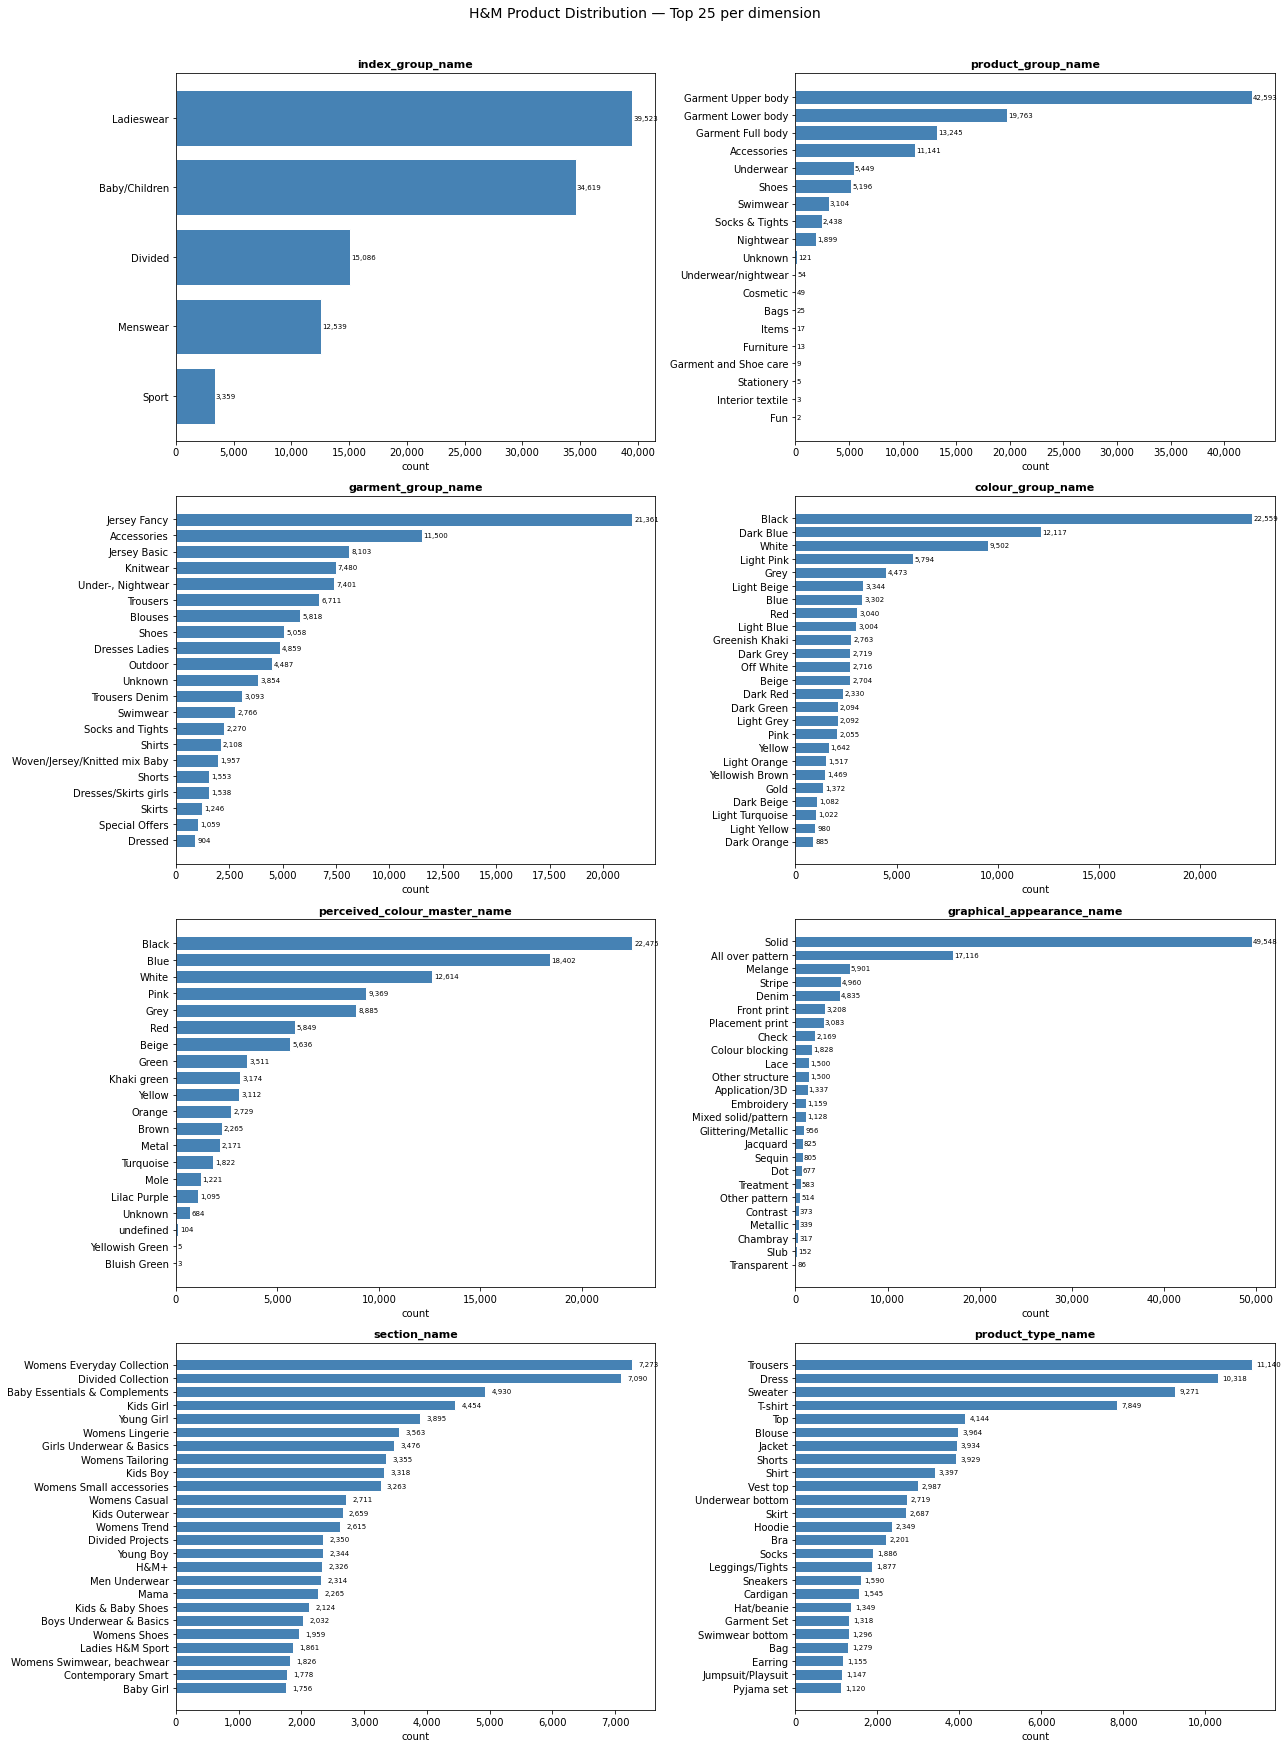

In [9]:
# ── Visual distributions ──────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(18, 24))
axes = axes.flatten()

for ax, col in zip(axes, STRAT_COLS):
    vc = df[col].value_counts().head(25)
    bars = ax.barh(vc.index[::-1], vc.values[::-1], color="steelblue", edgecolor="white")
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_xlabel("count")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    for bar, val in zip(bars, vc.values[::-1]):
        ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height() / 2,
                f"{val:,}", va="center", fontsize=7)

plt.suptitle("H&M Product Distribution — Top 25 per dimension", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("distributions.png", bbox_inches="tight", dpi=120)
plt.show()

In [10]:
# ── Cross-tab: index_group × product_group ────────────────────────────────────
ct = pd.crosstab(df["index_group_name"], df["product_group_name"])
ct["TOTAL"] = ct.sum(axis=1)
ct = ct.sort_values("TOTAL", ascending=False)
print(ct.to_string())

product_group_name  Accessories  Bags  Cosmetic  Fun  Furniture  Garment Full body  Garment Lower body  Garment Upper body  Garment and Shoe care  Interior textile  Items  Nightwear  Shoes  Socks & Tights  Stationery  Swimwear  Underwear  Underwear/nightwear  Unknown  TOTAL
index_group_name                                                                                                                                                                                                                                                                  
Ladieswear                 5202     1         0    0         13               5582                5720               14062                      9                 0     16        663   2026             577           5      1899       3692                    0       56  39523
Baby/Children              2923     2        49    2          0               4807                7350               13147                      0                 3      0     

In [11]:
# ── Cross-tab: index_group × garment_group ────────────────────────────────────
ct2 = pd.crosstab(df["index_group_name"], df["garment_group_name"])
ct2["TOTAL"] = ct2.sum(axis=1)
ct2 = ct2.sort_values("TOTAL", ascending=False)
print(ct2.to_string())

garment_group_name  Accessories  Blouses  Dressed  Dresses Ladies  Dresses/Skirts girls  Jersey Basic  Jersey Fancy  Knitwear  Outdoor  Shirts  Shoes  Shorts  Skirts  Socks and Tights  Special Offers  Swimwear  Trousers  Trousers Denim  Under-, Nightwear  Unknown  Woven/Jersey/Knitted mix Baby  TOTAL
index_group_name                                                                                                                                                                                                                                                                                             
Ladieswear                 4990     4476      620            2598                     0          1355          6141      2910     1021       0   1959     429     718               650             583      1826      2758             227               4478     1784                              0  39523
Baby/Children              3288        0        0               0                  1538       

In [12]:
# ── Proposed stratification key: index_group + garment_group ─────────────────
# This is the primary strata we'll use for sampling.
# Shows each cell size + what % of 600 it would earn proportionally.
TARGET = 600
strata = (
    df.groupby(["index_group_name", "garment_group_name"])
    .size()
    .reset_index(name="pool_size")
    .sort_values("pool_size", ascending=False)
)
strata["pct_of_total"] = (strata["pool_size"] / strata["pool_size"].sum() * 100).round(2)
strata["proportional_n"] = (strata["pct_of_total"] / 100 * TARGET).round(1)
strata["cumulative_pct"] = strata["pct_of_total"].cumsum().round(1)
print(strata.to_string(index=False))

index_group_name            garment_group_name  pool_size  pct_of_total  proportional_n  cumulative_pct
   Baby/Children                  Jersey Fancy       9091          8.65            51.9             8.6
      Ladieswear                  Jersey Fancy       6141          5.84            35.0            14.5
      Ladieswear                   Accessories       4990          4.75            28.5            19.2
      Ladieswear             Under-, Nightwear       4478          4.26            25.6            23.5
      Ladieswear                       Blouses       4476          4.26            25.6            27.8
   Baby/Children                  Jersey Basic       4178          3.97            23.8            31.7
   Baby/Children                   Accessories       3288          3.13            18.8            34.9
      Ladieswear                      Knitwear       2910          2.77            16.6            37.6
      Ladieswear                      Trousers       2758       

In [13]:
# ── Colour coverage check ─────────────────────────────────────────────────────
# After stratifying by index_group + garment_group, do we get good colour coverage?
# Check how many unique master colours each stratum has.
colour_coverage = (
    df.groupby(["index_group_name", "garment_group_name"])["perceived_colour_master_name"]
    .nunique()
    .reset_index(name="unique_colours")
    .sort_values("unique_colours", ascending=False)
)
print(colour_coverage.to_string(index=False))

index_group_name            garment_group_name  unique_colours
      Ladieswear                      Knitwear              19
      Ladieswear                       Blouses              19
      Ladieswear                Special Offers              19
      Ladieswear                  Jersey Fancy              18
         Divided                  Jersey Fancy              18
         Divided                      Trousers              18
      Ladieswear                   Accessories              18
      Ladieswear                       Dressed              18
   Baby/Children          Dresses/Skirts girls              18
   Baby/Children                   Accessories              18
         Divided                       Blouses              18
      Ladieswear                       Outdoor              18
      Ladieswear                         Shoes              18
      Ladieswear                      Trousers              18
      Ladieswear             Under-, Nightwear         

In [14]:
# ── How many product_type_names are there per index_group? ────────────────────
type_coverage = (
    df.groupby("index_group_name")["product_type_name"]
    .nunique()
    .reset_index(name="unique_product_types")
    .sort_values("unique_product_types", ascending=False)
)
print(type_coverage.to_string(index=False))

print()
# Full product_type distribution inside the top 3 index groups
for grp in df["index_group_name"].value_counts().head(3).index:
    sub = df[df["index_group_name"] == grp]["product_type_name"].value_counts().head(15)
    print(f"\n── {grp} — top 15 product types ──")
    print(sub.to_string())

index_group_name  unique_product_types
      Ladieswear                    99
   Baby/Children                    94
         Divided                    74
        Menswear                    65
           Sport                    33


── Ladieswear — top 15 product types ──
Dress               5381
Trousers            3274
Sweater             2876
Blouse              2815
Top                 2487
Bra                 1894
Underwear bottom    1512
Skirt               1409
T-shirt             1407
Vest top            1099
Earring             1091
Jacket               992
Bikini top           795
Shorts               736
Swimwear bottom      719

── Baby/Children — top 15 product types ──
Trousers             4161
T-shirt              3389
Sweater              2859
Dress                2489
Shorts               1643
Jacket               1511
Garment Set          1272
Leggings/Tights      1053
Hoodie               1011
Sneakers              921
Socks                 894
Top                

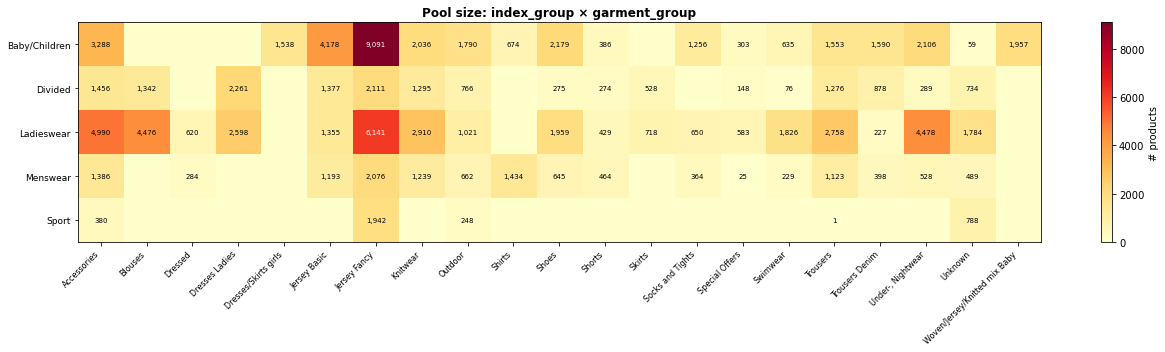

In [15]:
# ── Summary: strata sizes after index_group + garment_group ──────────────────
# Heatmap view of pool sizes across the two main strata dimensions
import numpy as np

pivot = df.groupby(["index_group_name", "garment_group_name"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(18, 5))
im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd")

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if val > 0:
            ax.text(j, i, f"{val:,}", ha="center", va="center",
                    fontsize=7, color="black" if val < pivot.values.max() * 0.6 else "white")

plt.colorbar(im, ax=ax, label="# products")
ax.set_title("Pool size: index_group × garment_group", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("strata_heatmap.png", bbox_inches="tight", dpi=120)
plt.show()

In [20]:
import numpy as np

# ── Strategic Sampling — 600 products ────────────────────────────────────────
TARGET = 600
MIN_PER_STRATUM = 3
SEED = 42

STRATA_KEYS = ["index_group_name", "product_group_name"]
DROP_COLS = ["dense_embedding", "sparse_indices", "sparse_values"]

pool = df.drop(columns=DROP_COLS, errors="ignore")

strata = (
    pool.groupby(STRATA_KEYS)
    .size()
    .reset_index(name="pool_size")
).copy()

# ── Phase 1: give every stratum its minimum (capped at pool_size) ─────────────
strata["alloc"] = strata["pool_size"].clip(upper=MIN_PER_STRATUM)
min_total = strata["alloc"].sum()

# ── Phase 2: distribute remaining budget proportionally among strata with room ─
budget = TARGET - min_total
strata["capacity"] = strata["pool_size"] - strata["alloc"]   # seats still available
grow = strata["capacity"] > 0

grow_capacity = strata.loc[grow, "capacity"]
strata["extra_raw"] = 0.0
strata.loc[grow, "extra_raw"] = grow_capacity / grow_capacity.sum() * budget

strata["extra_floor"] = np.floor(strata["extra_raw"]).astype(int).clip(upper=strata["capacity"])
strata["alloc"] += strata["extra_floor"]

# ── Phase 3: largest-remainder top-up to land at exactly TARGET ──────────────
deficit = TARGET - strata["alloc"].sum()
strata["remainder"] = strata["extra_raw"] - strata["extra_floor"]
eligible_idx = (
    strata[strata["alloc"] < strata["pool_size"]]
    ["remainder"].nlargest(deficit).index
)
strata.loc[eligible_idx, "alloc"] += 1

# safety loop for any residual (shouldn't trigger)
while strata["alloc"].sum() < TARGET:
    idx = strata[strata["alloc"] < strata["pool_size"]]["pool_size"].idxmax()
    strata.loc[idx, "alloc"] += 1

strata["final_n"] = strata["alloc"]

assert strata["final_n"].sum() == TARGET,        f"Got {strata['final_n'].sum()}, expected {TARGET}"
assert (strata["final_n"] <= strata["pool_size"]).all(), "Allocation exceeds pool!"

print(f"Allocated: {strata['final_n'].sum()} / {TARGET}  ✓")
print()
print(strata[STRATA_KEYS + ["pool_size", "final_n"]].sort_values("final_n", ascending=False).to_string(index=False))

AssertionError: Got 662, expected 600

In [ ]:
# ── Draw the sample ──────────────────────────────────────────────────────────
rng = np.random.default_rng(SEED)

frames = []
for _, row in strata.iterrows():
    mask = (pool[STRATA_KEYS[0]] == row[STRATA_KEYS[0]]) & \
           (pool[STRATA_KEYS[1]] == row[STRATA_KEYS[1]])
    sub = pool[mask]
    n = int(row["final_n"])
    if len(sub) <= n:
        frames.append(sub)
    else:
        frames.append(sub.sample(n=n, random_state=SEED))

sample_df = pd.concat(frames).reset_index(drop=True)




print(f"Final sample shape: {sample_df.shape}")
print()
print("Distribution by index_group_name:")
print(sample_df["index_group_name"].value_counts())
print()
print("Distribution by product_group_name:")
print(sample_df["product_group_name"].value_counts())
print()
print("Unique colours:", sample_df["perceived_colour_master_name"].nunique())
print("Unique product types:", sample_df["product_type_name"].nunique())
print("All have image_url:", sample_df["image_url"].notna().all())

Final sample shape: (593, 27)

Distribution by index_group_name:
Ladieswear       208
Baby/Children    185
Divided           89
Menswear          78
Sport             33
Name: index_group_name, dtype: int64

Distribution by product_group_name:
Garment Upper body       209
Garment Lower body        97
Garment Full body         71
Accessories               56
Underwear                 31
Shoes                     29
Swimwear                  22
Socks & Tights            18
Unknown                   15
Nightwear                 12
Bags                       9
Items                      4
Cosmetic                   3
Interior textile           3
Furniture                  3
Garment and Shoe care      3
Stationery                 3
Underwear/nightwear        3
Fun                        2
Name: product_group_name, dtype: int64

Unique colours: 17
Unique product types: 83
All have image_url: True


In [18]:
# ── Export ───────────────────────────────────────────────────────────────────
import os, json

OUT_DIR = "../data"
os.makedirs(OUT_DIR, exist_ok=True)

csv_path  = os.path.join(OUT_DIR, "products.csv")
json_path = os.path.join(OUT_DIR, "products.json")

sample_df.to_csv(csv_path, index=False)
sample_df.to_json(json_path, orient="records", indent=2)

print(f"Saved {len(sample_df)} products")
print(f"  CSV  → {csv_path}  ({os.path.getsize(csv_path)/1024:.1f} KB)")
print(f"  JSON → {json_path}  ({os.path.getsize(json_path)/1024:.1f} KB)")

Saved 593 products
  CSV  → ../data/products.csv  (424.8 KB)
  JSON → ../data/products.json  (830.7 KB)
